# **Burned Area Segmentation Using U-Net on Sentinel-2 Imagery**

This notebook presents an end-to-end pipeline for burned area segmentation using Sentinel-2 satellite imagery.
The workflow includes data preprocessing, patch extraction, dataset splitting, model training with advanced optimization techniques, and comprehensive evaluation on validation and test sets.

**Model:** U-Net (ResNet18 encoder)  
**Task:** Binary semantic segmentation (burned vs. non-burned)  
**Dataset:** Sentinel-2 burned area patches  
**Dataset Link :** https://zenodo.org/records/6597139?utm_source=chatgpt.com


In [9]:
!pip install segmentation_models_pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.5 MB/s eta 0:00:00


In [1]:
# Drive bağlama
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p /content/burned_area


In [3]:
import zipfile
import os

ZIP_ROOT = "/content/drive/MyDrive/burned_area"
OUT_ROOT = "/content/burned_area"

# part1.zip, part2.zip, ...
for fname in os.listdir(ZIP_ROOT):
    if fname.endswith(".zip"):
        part_name = fname.replace(".zip", "")
        out_dir = os.path.join(OUT_ROOT, part_name)
        os.makedirs(out_dir, exist_ok=True)

        print(f"Açılıyor: {fname}")
        with zipfile.ZipFile(os.path.join(ZIP_ROOT, fname), "r") as z:
            z.extractall(out_dir)


Açılıyor: Satellite_burned_area_dataset_part1.zip
Açılıyor: Satellite_burned_area_dataset_part2.zip
Açılıyor: Satellite_burned_area_dataset_part3.zip
Açılıyor: Satellite_burned_area_dataset_part4.zip
Açılıyor: Satellite_burned_area_dataset_part5.zip


## **Dataset Preparation and Patch Generation**

The raw Sentinel-2 dataset consists of large GeoTIFF images along with corresponding burned area masks.
To enable efficient training of convolutional neural networks, the images are divided into fixed-size patches.

**Key preprocessing steps:**
- Sentinel-2 RGB bands (B2, B3, B4) are extracted.
- Images are split into non-overlapping patches of size 256×256.
- Patches with empty masks (no burned pixels) are discarded.
- Each patch pair (image, mask) is stored as NumPy arrays.

This patch-based strategy significantly reduces memory usage and enables scalable model training.


In [4]:
import os
import rasterio
from rasterio.windows import Window
import numpy as np
from tqdm import tqdm

BASE_ROOT = "/content/burned_area"
OUT = "/content/burned_tiles"

os.makedirs(f"{OUT}/x", exist_ok=True)
os.makedirs(f"{OUT}/y", exist_ok=True)

TILE = 256
idx = 0

# === PART1 → PART5 ===
for part in sorted(os.listdir(BASE_ROOT)):
    part_dir = os.path.join(BASE_ROOT, part)
    if not os.path.isdir(part_dir):
        continue

    # İçteki gerçek dataset klasörü
    subdirs = [
        d for d in os.listdir(part_dir)
        if os.path.isdir(os.path.join(part_dir, d))
    ]
    if not subdirs:
        continue

    ROOT = os.path.join(part_dir, subdirs[0])
    print(f"\nİşleniyor: {ROOT}")

    for event in tqdm(os.listdir(ROOT)):
        evdir = os.path.join(ROOT, event)
        if not os.path.isdir(evdir):
            continue

        # Mask dosyasını bul
        masks = [f for f in os.listdir(evdir) if "mask" in f.lower()]

        # SADECE gerçek Sentinel-2 (cloud hariç)
        s2s = [
            f for f in os.listdir(evdir)
            if f.lower().startswith("sentinel2_")
            and f.lower().endswith(".tiff")
            and "cloud" not in f.lower()
        ]

        if not masks or not s2s:
            continue

        # Mask oku
        with rasterio.open(os.path.join(evdir, masks[0])) as msk_src:
            mask_arr = msk_src.read(1)

        for s2 in s2s:
            with rasterio.open(os.path.join(evdir, s2)) as src:

                # Güvenlik kontrolü (RGB için)
                if src.count < 3:
                    continue

                H, W = src.height, src.width

                for top in range(0, H - TILE + 1, TILE):
                    for left in range(0, W - TILE + 1, TILE):
                        w = Window(left, top, TILE, TILE)

                        # Sentinel-2 DOĞRU RGB
                        img_patch = src.read([1, 2, 3], window=w).astype(np.float32)
                        mask_patch = mask_arr[top:top+TILE, left:left+TILE]

                        # Mask boşsa atla
                        if np.all(mask_patch == 0):
                            continue

                        np.save(f"{OUT}/x/{idx:06d}.npy", img_patch)
                        np.save(f"{OUT}/y/{idx:06d}.npy", mask_patch)
                        idx += 1

print(f"\nToplam patch sayısı: {idx}")



İşleniyor: /content/burned_area/Satellite_burned_area_dataset_part1/Satellite_burned_area_dataset_part1


  0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
100%|██████████| 17/17 [00:31<00:00,  1.83s/it]



İşleniyor: /content/burned_area/Satellite_burned_area_dataset_part2/Satellite_burned_area_dataset_part2


100%|██████████| 11/11 [00:37<00:00,  3.38s/it]



İşleniyor: /content/burned_area/Satellite_burned_area_dataset_part3/Satellite_burned_area_dataset_part3


...


İşleniyor: /content/burned_area/Satellite_burned_area_dataset_part4/Satellite_burned_area_dataset_part4


100%|██████████| 7/7 [00:32<00:00,  4.61s/it]



İşleniyor: /content/burned_area/Satellite_burned_area_dataset_part5/Satellite_burned_area_dataset_part5


100%|██████████| 9/9 [00:18<00:00,  2.08s/it]


Toplam patch sayısı: 2330


## **Dataset Splitting**

The extracted patches are randomly split into training, validation, and test sets using a patch-level strategy.

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

This split allows for efficient model development and hyperparameter tuning.  
While this approach may introduce spatial overlap between patches from the same wildfire event, it provides a strong baseline for model evaluation.


In [8]:
import os
import random
import numpy as np

TILES_DIR = "/content/burned_tiles"
x_dir = os.path.join(TILES_DIR, "x")
y_dir = os.path.join(TILES_DIR, "y")

ids = sorted([os.path.splitext(f)[0] for f in os.listdir(x_dir) if f.endswith(".npy")])

random.seed(42)
random.shuffle(ids)

n = len(ids)
train_ids = ids[:int(0.7*n)]
val_ids   = ids[int(0.7*n):int(0.85*n)]
test_ids  = ids[int(0.85*n):]

print("Train:", len(train_ids), "Val:", len(val_ids), "Test:", len(test_ids))


Train: 1631 Val: 349 Test: 350


In [10]:
import torch
from torch.utils.data import Dataset
import numpy as np
import os

class BurnedPatchDataset(Dataset):
    def __init__(self, tiles_dir, ids, normalize=True):
        self.tiles_dir = tiles_dir
        self.ids = ids
        self.normalize = normalize

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]

        x = np.load(os.path.join(self.tiles_dir, "x", f"{id_}.npy"))
        y = np.load(os.path.join(self.tiles_dir, "y", f"{id_}.npy"))

        # (H,W,C) gelirse düzelt
        if x.ndim == 3 and x.shape[-1] == 3:
            x = np.transpose(x, (2, 0, 1))

        x = x.astype(np.float32)
        if self.normalize:
            x = x / 255.0

        y = (y > 0).astype(np.int64)

        return torch.from_numpy(x), torch.from_numpy(y)


## **Dataset and DataLoader Definition**

A custom PyTorch `Dataset` class is implemented to load image–mask pairs from disk.
Each sample consists of:
- A normalized RGB image tensor of shape (3, 256, 256)
- A binary segmentation mask of shape (256, 256)

PyTorch `DataLoader`s are used to enable efficient mini-batch loading and shuffling during training.


In [11]:
from torch.utils.data import DataLoader

train_ds = BurnedPatchDataset(TILES_DIR, train_ids)
val_ds   = BurnedPatchDataset(TILES_DIR, val_ids)
test_ds  = BurnedPatchDataset(TILES_DIR, test_ids)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)


## **Model Architecture**

The segmentation model is based on the U-Net architecture with a ResNet18 encoder pretrained on ImageNet.

**Architecture details:**
- Encoder: ResNet18 (pretrained)
- Decoder: U-Net decoder
- Input channels: 3 (RGB)
- Output: 1-channel binary segmentation mask

U-Net is well-suited for this task due to its ability to preserve spatial details through skip connections.


In [12]:
import segmentation_models_pytorch as smp
import torch

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

# **Training-1**

##Baseline Training

This training represents a **basic U-Net baseline** using a standard train–validation loop.  
The model is trained for 20 epochs with a fixed optimizer and loss function, without any advanced optimization techniques.

During each epoch:
- Model parameters are updated on the training set.
- Performance is evaluated on a separate validation set without gradient updates.

Training and validation losses are recorded to monitor convergence and provide a reference baseline for later, more advanced training strategies.


In [ ]:
from tqdm import tqdm

EPOCHS = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # === TRAIN ===
    model.train()
    train_loss = 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        x = x.to(device)
        y = y.unsqueeze(1).float().to(device)  # (B,1,H,W)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # === VALIDATION ===
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            x = x.to(device)
            y = y.unsqueeze(1).float().to(device)

            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")


Epoch 1/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 22.89it/s]


Epoch 1: Train Loss=0.5901, Val Loss=0.5029


Epoch 2/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 30.08it/s]


Epoch 2: Train Loss=0.4789, Val Loss=0.4836


Epoch 3/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 24.76it/s]


...

Epoch 18: Train Loss=0.1335, Val Loss=0.4122


Epoch 19/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 29.31it/s]


Epoch 19: Train Loss=0.1477, Val Loss=0.4599


Epoch 20/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 26.53it/s]

Epoch 20: Train Loss=0.0937, Val Loss=0.3649


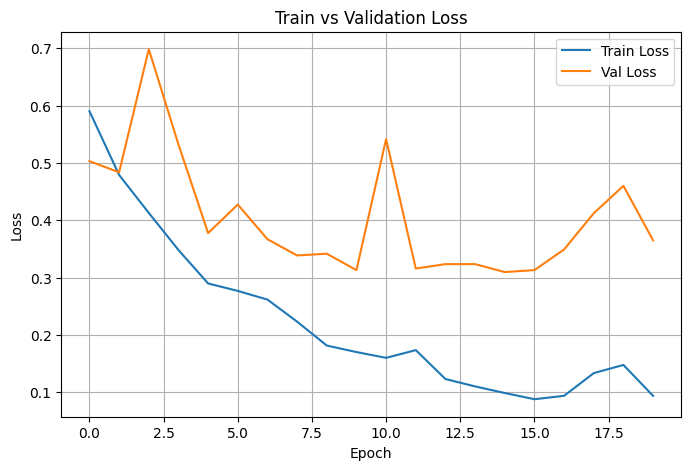

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import torch

def dice_score(pred, target, eps=1e-7):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_score(pred, target, eps=1e-7):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


In [ ]:
model.eval()

test_loss = 0.0
test_dice = 0.0
test_iou = 0.0

criterion = torch.nn.BCEWithLogitsLoss()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.unsqueeze(1).float().to(device)

        logits = model(x)
        loss = criterion(logits, y)

        probs = torch.sigmoid(logits)

        test_loss += loss.item()
        test_dice += dice_score(probs, y)
        test_iou += iou_score(probs, y)

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)

print(f"TEST RESULTS")
print(f"Loss : {test_loss:.4f}")
print(f"Dice : {test_dice:.4f}")
print(f"IoU  : {test_iou:.4f}")


TEST RESULTS
Loss : 0.3402
Dice : 0.6721
IoU  : 0.6169


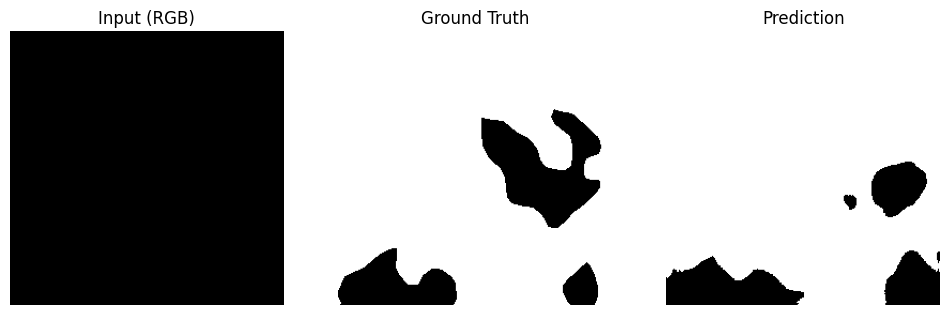

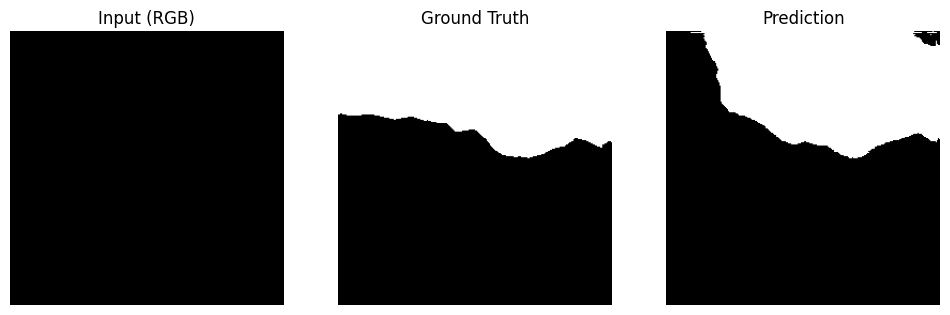

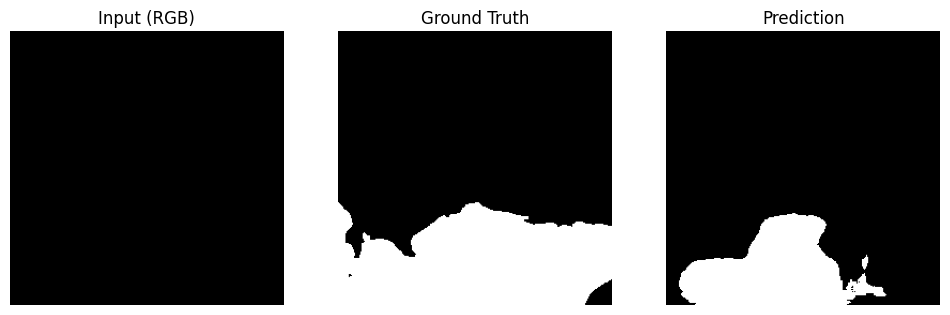

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

x, y = next(iter(test_loader))
x = x.to(device)
y = y.unsqueeze(1).float().to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.sigmoid(logits)

# CPU'ya al
x = x.cpu().numpy()
y = y.cpu().numpy()
probs = probs.cpu().numpy()

# İlk N örnek
N = 3

for i in range(N):
    img = x[i]          # (C,H,W)
    gt = y[i,0]         # (H,W)
    pred = probs[i,0]   # (H,W)

    # RGB'ye çevir
    img_rgb = np.transpose(img, (1,2,0))
    img_rgb = np.clip(img_rgb, 0, 1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Input (RGB)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred > 0.5, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()


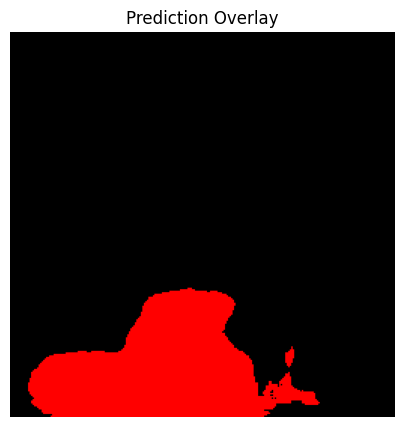

In [ ]:
overlay = img_rgb.copy()
overlay[pred > 0.5] = [1, 0, 0]  # kırmızı

plt.figure(figsize=(5,5))
plt.imshow(overlay)
plt.title("Prediction Overlay")
plt.axis("off")
plt.show()


# **Training-2**

## Training-2: Dice-Enhanced Training with Early Stopping

In this training setup, the baseline U-Net model is improved by using a **combined loss function (BCE + Dice)**, which is better suited for binary segmentation tasks with class imbalance. In addition to loss values, **Dice score and IoU** are computed on the validation set to directly measure segmentation quality.

An **early stopping mechanism** is applied based on validation loss, allowing training to terminate automatically when performance no longer improves. The best-performing model is saved during training.

This configuration provides a more reliable and segmentation-focused baseline compared to the initial training.


In [18]:
import torch
import segmentation_models_pytorch as smp
from tqdm import tqdm

# Loss: BCE + Dice (en stabil kombinasyon)
bce_loss  = torch.nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode="binary")

def combined_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)

# Metricler (log için)
def dice_score(pred, target, eps=1e-7):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2 * intersection + eps) / (union + eps)).mean().item()

def iou_score(pred, target, eps=1e-7):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) - intersection + target.sum(dim=(1,2,3))
    return ((intersection + eps) / (union + eps)).mean().item()


In [19]:
EPOCHS = 20
PATIENCE = 5   # early stopping sabrı

train_losses = []
val_losses   = []
val_dices    = []
val_ious     = []

best_val_loss = float("inf")
patience_cnt = 0

for epoch in range(EPOCHS):
    # ===================== TRAIN =====================
    model.train()
    train_loss = 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        x = x.to(device)
        y = y.unsqueeze(1).float().to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = combined_loss(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0.0
    dice_sum = 0.0
    iou_sum  = 0.0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            x = x.to(device)
            y = y.unsqueeze(1).float().to(device)

            logits = model(x)
            loss = combined_loss(logits, y)
            probs = torch.sigmoid(logits)

            val_loss += loss.item()
            dice_sum += dice_score(probs, y)
            iou_sum  += iou_score(probs, y)

    val_loss /= len(val_loader)
    val_dice = dice_sum / len(val_loader)
    val_iou  = iou_sum / len(val_loader)

    val_losses.append(val_loss)
    val_dices.append(val_dice)
    val_ious.append(val_iou)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    # ===================== EARLY STOPPING =====================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("  ✓ Best model saved")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print("⛔ Early stopping triggered")
            break


Epoch 1/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 29.76it/s]


Epoch 01 | Train Loss: 0.1302 | Val Loss: 0.4900 | Dice: 0.6783 | IoU: 0.6183
  ✓ Best model saved


Epoch 2/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 25.93it/s]


Epoch 02 | Train Loss: 0.1322 | Val Loss: 0.4970 | Dice: 0.6628 | IoU: 0.6080


Epoch 3/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 29.27it/s]


...

Epoch 04 | Train Loss: 0.1408 | Val Loss: 0.8015 | Dice: 0.5633 | IoU: 0.4895


Epoch 5/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 23.38it/s]


Epoch 05 | Train Loss: 0.2415 | Val Loss: 0.6591 | Dice: 0.6647 | IoU: 0.6016


Epoch 6/20 [Val]: 100%|██████████| 44/44 [00:01<00:00, 28.98it/s]

Epoch 06 | Train Loss: 0.1713 | Val Loss: 0.4901 | Dice: 0.7073 | IoU: 0.6456
⛔ Early stopping triggered


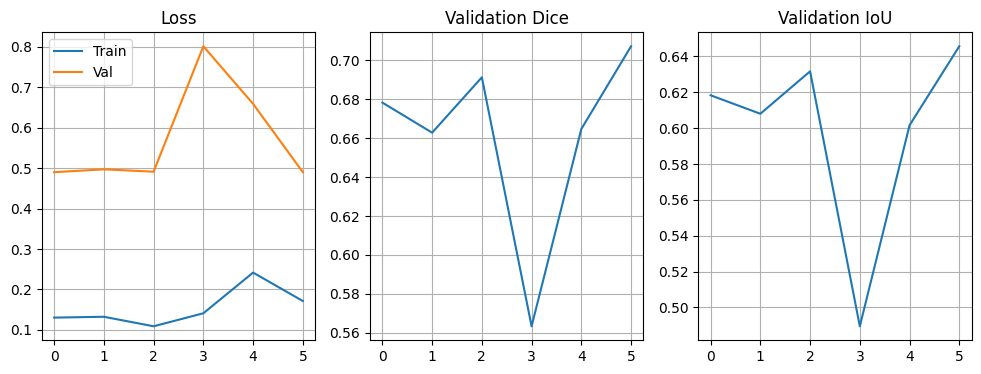

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,3,2)
plt.plot(val_dices)
plt.title("Validation Dice")
plt.grid()

plt.subplot(1,3,3)
plt.plot(val_ious)
plt.title("Validation IoU")
plt.grid()

plt.show()


# **Training-3**

## Fully Optimized Training Strategy

This training configuration represents the **final and most advanced setup** used in this study.  
The model is optimized using a combination of **Focal Loss and Dice Loss**, which improves learning on imbalanced burned area regions and enhances segmentation overlap quality.

Several advanced techniques are integrated into a single training loop:
- **Learning rate scheduling** with ReduceLROnPlateau to adaptively lower the learning rate.
- **Mixed precision training (AMP)** for faster and more stable optimization.
- **Gradient clipping** to prevent unstable updates.
- **Encoder freezing and fine-tuning**, allowing the decoder to stabilize before updating encoder weights.
- **Early stopping and checkpointing based on Dice score**, ensuring the best segmentation performance is retained.

This configuration achieves the highest validation and test performance and serves as the final model used for evaluation.


In [22]:
# ==== OPTIMIZED TRAINING LOOP (single block, no 'verbose' arg) ====
import torch
import segmentation_models_pytorch as smp
from tqdm import tqdm

# -------------------------
# Loss (Focal + Dice)
# -------------------------
dice_loss  = smp.losses.DiceLoss(mode="binary")
focal_loss = smp.losses.FocalLoss(mode="binary", alpha=0.8, gamma=2.0)

def combined_loss(logits, targets):
    return focal_loss(logits, targets) + dice_loss(logits, targets)

# -------------------------
# Metrics
# -------------------------
@torch.no_grad()
def dice_score_from_probs(probs, target, thr=0.5, eps=1e-7):
    pred = (probs > thr).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2 * inter + eps) / (union + eps)).mean().item()

@torch.no_grad()
def iou_score_from_probs(probs, target, thr=0.5, eps=1e-7):
    pred = (probs > thr).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()

# -------------------------
# Optimizer + Scheduler (no verbose)
# -------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)

# -------------------------
# Mixed Precision
# -------------------------
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# -------------------------
# Optional: Encoder freeze warmup
# -------------------------
FREEZE_EPOCHS = 2  # set 0 to disable
if FREEZE_EPOCHS > 0:
    for p in model.encoder.parameters():
        p.requires_grad = False

# -------------------------
# Early stopping + checkpoint on Dice
# -------------------------
EPOCHS = 30
PATIENCE = 6
GRAD_CLIP = 1.0

train_losses, val_losses, val_dices, val_ious, lrs = [], [], [], [], []

best_val_dice = -1.0
best_epoch = -1
patience_cnt = 0
prev_lr = optimizer.param_groups[0]["lr"]

for epoch in range(EPOCHS):
    # unfreeze encoder after warmup
    if FREEZE_EPOCHS > 0 and epoch == FREEZE_EPOCHS:
        for p in model.encoder.parameters():
            p.requires_grad = True
        # re-init optimizer/scheduler after unfreezing (stable)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
        )
        prev_lr = optimizer.param_groups[0]["lr"]

    # ===================== TRAIN =====================
    model.train()
    running_train = 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        x = x.to(device, non_blocking=True)
        y = y.unsqueeze(1).float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x)
            loss = combined_loss(logits, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        running_train += loss.item()

    train_loss = running_train / max(1, len(train_loader))
    train_losses.append(train_loss)

    # ===================== VAL =====================
    model.eval()
    running_val = 0.0
    dice_sum, iou_sum = 0.0, 0.0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            x = x.to(device, non_blocking=True)
            y = y.unsqueeze(1).float().to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x)
                loss = combined_loss(logits, y)

            probs = torch.sigmoid(logits)

            running_val += loss.item()
            dice_sum += dice_score_from_probs(probs, y)
            iou_sum  += iou_score_from_probs(probs, y)

    val_loss = running_val / max(1, len(val_loader))
    val_dice = dice_sum / max(1, len(val_loader))
    val_iou  = iou_sum  / max(1, len(val_loader))

    val_losses.append(val_loss)
    val_dices.append(val_dice)
    val_ious.append(val_iou)

    # scheduler on val_loss
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    lrs.append(current_lr)
    lr_note = ""
    if current_lr != prev_lr:
        lr_note = f" | LR changed: {prev_lr:.2e} -> {current_lr:.2e}"
        prev_lr = current_lr

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.2e}"
        f"{lr_note}"
    )

    # checkpoint on val_dice
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_epoch = epoch + 1
        patience_cnt = 0
        torch.save(
            {
                "epoch": best_epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val_dice": best_val_dice,
            },
            "best_model_dice.pth",
        )
        print("  ✓ Best model saved (by Dice)")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"⛔ Early stopping (best epoch: {best_epoch}, best Dice: {best_val_dice:.4f})")
            break


/tmp/ipython-input-810323869.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/30 [Train]:   0%|          | 0/204 [00:00<?, ?it/s]/tmp/ipython-input-810323869.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/30 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]/tmp/ipython-input-810323869.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/30 [Val]: 100%|██████████| 44/44 [00:01<00:00, 32.30it/s]


Epoch 01 | Train Loss: 0.0530 | Val Loss: 0.2744 | Dice: 0.7125 | IoU: 0.6511 | LR: 2.00e-04
  ✓ Best model saved (by Dice)


Epoch 2/30 [Val]: 100%|██████████| 44/44 [00:01<00:00, 27.93it/s]


Epoch 02 | Train Loss: 0.0493 | Val Loss: 0.3018 | Dice: 0.7120 | IoU: 0.6519 | LR: 2.00e-04


Epoch 3/30 [Val]: 100%|██████████| 44/44 [00:01<00:00, 32.80it/s]


...

Epoch 17 | Train Loss: 0.0181 | Val Loss: 0.3330 | Dice: 0.7495 | IoU: 0.6951 | LR: 6.25e-06


Epoch 18/30 [Val]: 100%|██████████| 44/44 [00:01<00:00, 35.42it/s]


Epoch 18 | Train Loss: 0.0177 | Val Loss: 0.3411 | Dice: 0.7396 | IoU: 0.6868 | LR: 6.25e-06


Epoch 19/30 [Val]: 100%|██████████| 44/44 [00:01<00:00, 35.60it/s]

Epoch 19 | Train Loss: 0.0183 | Val Loss: 0.3423 | Dice: 0.7433 | IoU: 0.6907 | LR: 3.13e-06 | LR changed: 6.25e-06 -> 3.13e-06
⛔ Early stopping (best epoch: 13, best Dice: 0.7508)


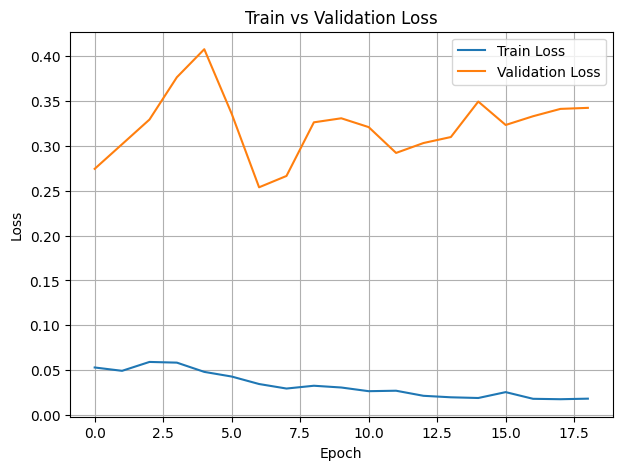

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


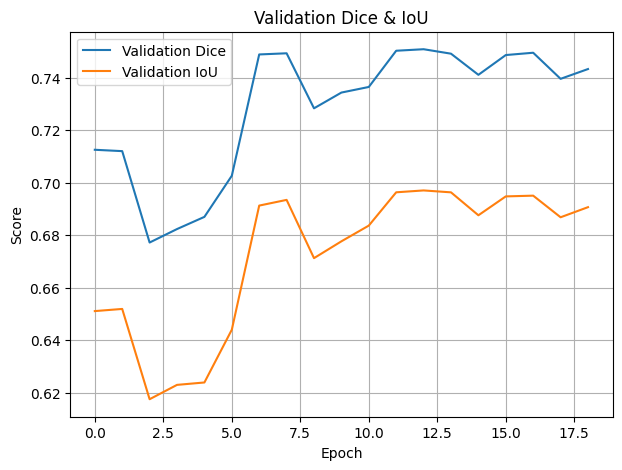

In [24]:
plt.figure(figsize=(7,5))
plt.plot(val_dices, label="Validation Dice")
plt.plot(val_ious, label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Dice & IoU")
plt.legend()
plt.grid(True)
plt.show()


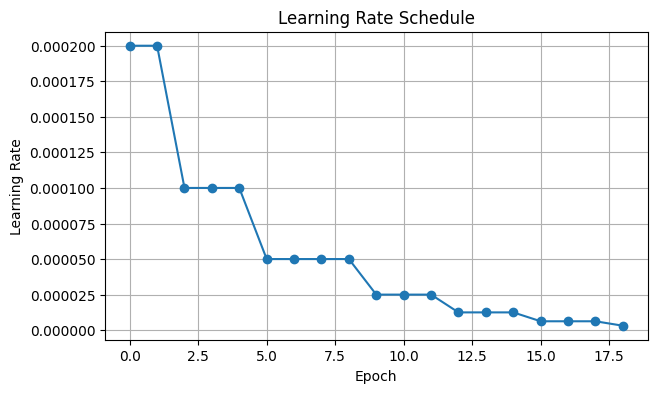

In [25]:
plt.figure(figsize=(7,4))
plt.plot(lrs, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.show()


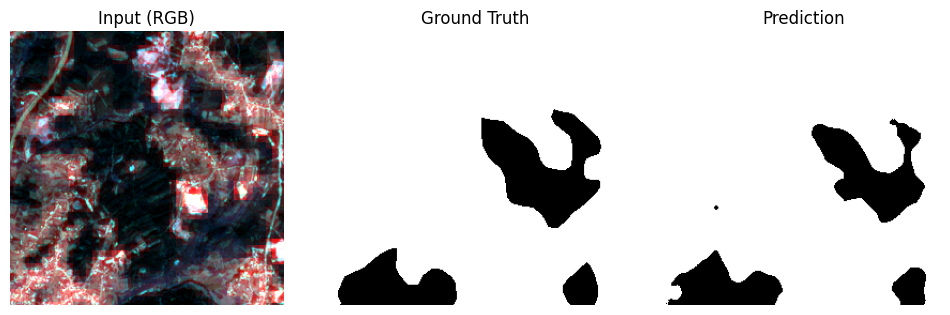

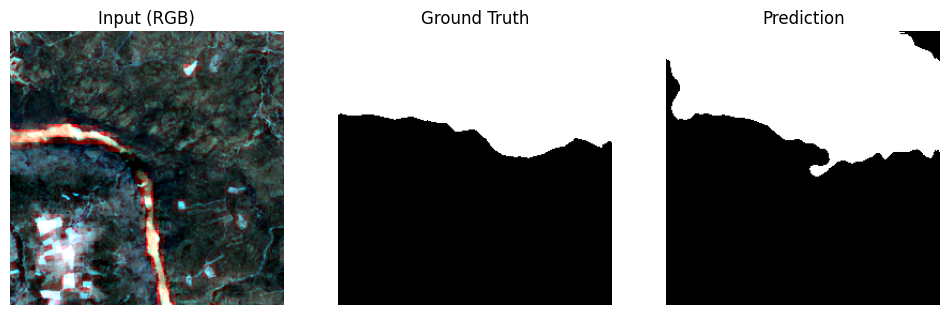

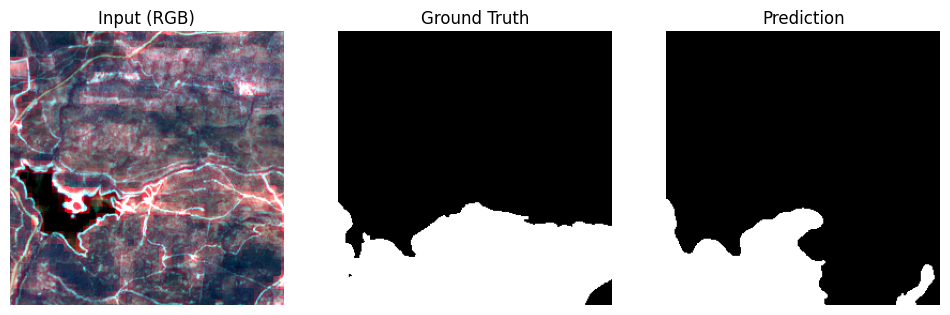

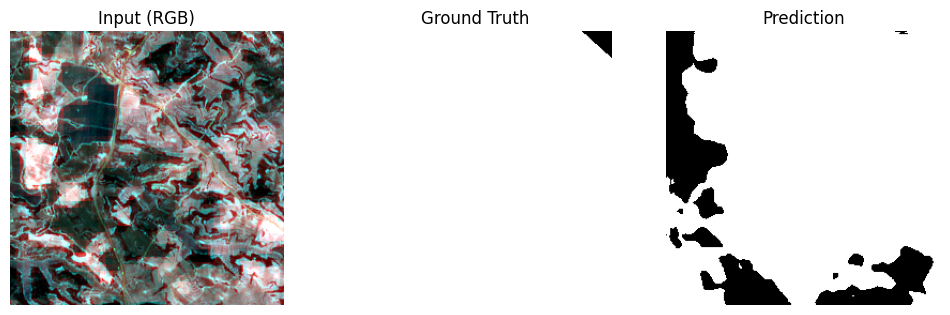

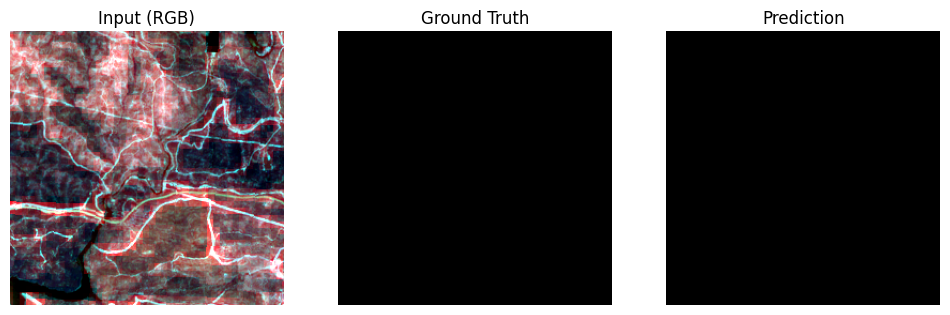

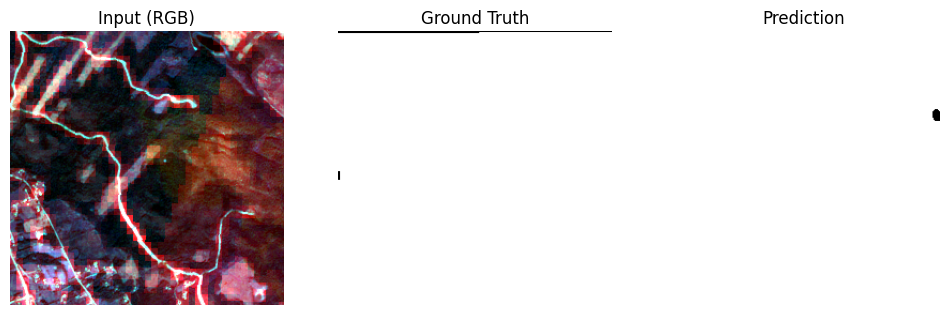

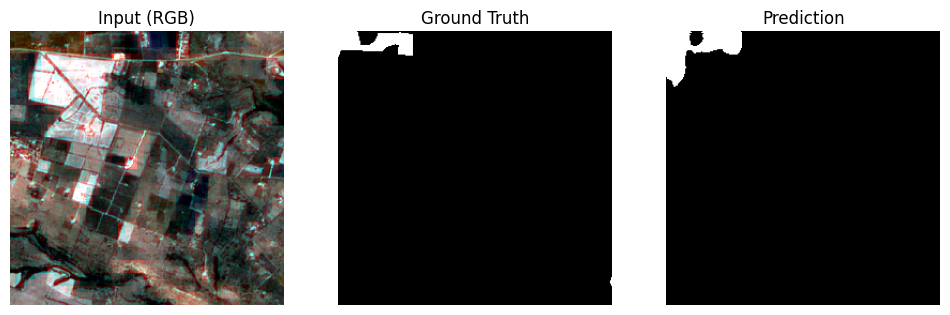

In [35]:
def normalize_for_display(img, pmin=2, pmax=98):
    """
    img: (H,W,C) float
    """
    out = np.zeros_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        lo, hi = np.percentile(img[..., c], (pmin, pmax))
        out[..., c] = np.clip((img[..., c] - lo) / (hi - lo + 1e-6), 0, 1)
    return out



import numpy as np
import matplotlib.pyplot as plt

model.eval()
x, y = next(iter(test_loader))
x = x.to(device)
y = y.unsqueeze(1).float().to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(x))

x = x.cpu().numpy()
y = y.cpu().numpy()
probs = probs.cpu().numpy()

N = 7

for i in range(N):
    img = np.transpose(x[i], (1,2,0))   # (H,W,C)
    gt  = y[i,0]
    pr  = probs[i,0]

    # 🔥 DOĞRU GÖRSELLEŞTİRME
    img_vis = normalize_for_display(img)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_vis)
    plt.title("Input (RGB)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pr > 0.5, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()


In [27]:
test_loss = 0.0
test_dice = 0.0
test_iou  = 0.0

criterion = combined_loss  # focal + dice

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.unsqueeze(1).float().to(device)

        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)

        test_loss += loss.item()
        test_dice += dice_score_from_probs(probs, y)
        test_iou  += iou_score_from_probs(probs, y)

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou  /= len(test_loader)

print("===== TEST RESULTS =====")
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")


===== TEST RESULTS =====
Test Loss : 0.3356
Test Dice : 0.7243
Test IoU  : 0.6728


In [26]:
ckpt = torch.load("best_model_dice.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

print("Loaded model from epoch:", ckpt["epoch"])
print("Best Val Dice:", ckpt["best_val_dice"])


Loaded model from epoch: 13
Best Val Dice: 0.7508426200259816
